## Avances del proyecto - Proyecto de aula
---------------------------------------------------------

 ## **1. Base de datos seleccionada con datos depurados**







Estos pasos son solo ilustrativos, los datos ya se encuentran en la carpeta /datos del repositorio

In [65]:
pip install ucimlrepo

In [79]:
#importacion de librerias y carga de dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("https://archive.ics.uci.edu/static/public/849/data.csv")
df.dropna(inplace=True, axis=0)

In [80]:
#Informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [81]:
#Creacion de variables discretas derivadas de la columna DateTime

df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Day'] = df['DateTime'].dt.day_name()     # Día de la semana
df['Hour'] = df['DateTime'].dt.hour          # Hora del día



In [82]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
52411,False
52412,False
52413,False
52414,False


In [83]:
#Seleccion de variables
df = df[['Day', 'Hour','Temperature', 'Humidity', 'Wind Speed',  'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']]

In [84]:
#Tabla descriptiva de las variables
variables = {
    'Day': ['Discreta', 'Día de la semana del registro', 'Derivada de DateTime'],
    'Hour': ['Discreta', 'Hora del día del registro', 'Derivada de DateTime'],
    'Temperature': ['Continua', 'Temperatura ambiente en °C', 'UCI Machine Learning Repository'],
    'Humidity': ['Continua', 'Porcentaje de humedad del aire', 'UCI Machine Learning Repository'],
    'Wind Speed': ['Continua', 'Velocidad del viento en km/h', 'UCI Machine Learning Repository'],
    'Zone 1 Power Consumption': ['Continua', 'Consumo eléctrico (kWh) de la Zona 1', 'UCI Machine Learning Repository'],
    'Zone 2 Power Consumption': ['Continua', 'Consumo eléctrico (kWh) de la Zona 2', 'UCI Machine Learning Repository'],
    'Zone 3 Power Consumption': ['Continua', 'Consumo eléctrico (kWh) de la Zona 3', 'UCI Machine Learning Repository']


}

tabla_vars = pd.DataFrame(variables, index=['Tipo', 'Definición', 'Fuente']).T
tabla_vars


,Tipo,Definición,Fuente
Day,Discreta,Día de la semana del registro,Derivada de DateTime
Hour,Discreta,Hora del día del registro,Derivada de DateTime
Temperature,Continua,Temperatura ambiente en °C,UCI Machine Learning Repository
Humidity,Continua,Porcentaje de humedad del aire,UCI Machine Learning Repository
Wind Speed,Continua,Velocidad del viento en km/h,UCI Machine Learning Repository
Zone 1 Power Consumption,Continua,Consumo eléctrico (kWh) de la Zona 1,UCI Machine Learning Repository
Zone 2 Power Consumption,Continua,Consumo eléctrico (kWh) de la Zona 2,UCI Machine Learning Repository
Zone 3 Power Consumption,Continua,Consumo eléctrico (kWh) de la Zona 3,UCI Machine Learning Repository


In [85]:
df.head()

,Day,Hour,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,Sunday,0,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,Sunday,0,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,Sunday,0,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,Sunday,0,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,Sunday,0,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


In [86]:
# Guardar los datos depurados
df.to_csv("Tetuan_City_power_consumption_clean.csv", index=False)

##**2. Análisis exploratorio**

###**Estadisticos descriptivos de las variables seleccionadas**

In [87]:

# Variables continuas de interés
variables = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption','Temperature','Humidity','Wind Speed']

# Crear un diccionario con los estadísticos
estadisticos = {}

for var in variables:
    moda = df[var].mode()[0] if not df[var].mode().empty else None
    rango = df[var].max() - df[var].min()

    estadisticos[var] = {
        'Media': df[var].mean(),
        'Mediana': df[var].median(),
        'Moda': moda,
        'Varianza': df[var].var(),
        'Desv.Estándar': df[var].std(),
        'Rango': rango,
        'Asimetría': df[var].skew(),
        'Curtosis': df[var].kurt()
    }

# Convertir a DataFrame
tabla_estadisticos = pd.DataFrame(estadisticos).T

# Mostrar tabla redondeada
tabla_estadisticos = tabla_estadisticos.round(3)
tabla_estadisticos


,Media,Mediana,Moda,Varianza,Desv.Estándar,Rango,Asimetría,Curtosis
Zone 1 Power Consumption,32344.971,32265.920,34560.000,5.084492e+07,7130.563,38308.699,0.229,-0.754
Zone 2 Power Consumption,21042.509,20823.168,21600.000,2.705525e+07,5201.466,28848.779,0.329,-0.437
Zone 3 Power Consumption,17835.406,16415.117,17280.000,4.385307e+07,6622.165,41663.152,1.024,1.086
Temperature,18.810,18.780,15.180,3.382000e+01,5.815,36.763,0.197,-0.303
Humidity,68.260,69.860,85.900,2.418390e+02,15.551,83.460,-0.625,-0.122
Wind Speed,1.959,0.086,0.082,5.517000e+00,2.349,6.433,0.462,-1.783




1.   Zona 1 tiene el mayor promedio de consumo (32,344) y también la mayor variabilidad, lo que sugiere que en esta zona hay más actividad o fluctuaciones en la demanda eléctrica.
Su asimetría positiva (0.23) indica que hay algunos días con consumos muy altos, aunque no extremos (curtosis negativa).
2.   La Zona 2 presenta un consumo intermedio y más estable, con menor variabilidad y una distribución más equilibrada respecto a las otras zonas, lo que sugiere un patrón de demanda más regular.
3. Zona 3 presenta el menor promedio (≈17,835) pero también una mayor asimetría (1.02) y curtosis positiva (1.08), lo que significa que hay más valores extremos — algunos picos de consumo alto — aunque la mayoría de los registros están por debajo del promedio.

4. La humedad es alta en general (68 % promedio) y tiene asimetría negativa, lo que sugiere que hay más registros con humedad alta que baja.

5. La velocidad del viento tiene una media baja (≈2 km/h) y una distribución muy sesgada hacia valores pequeños, lo que indica que los días con viento fuerte son poco frecuentes.

6. La temperatura promedio es de unos 18.8 °C, con poca variabilidad y una distribución bastante equilibrada.



###**Visualizaciones univariadas**

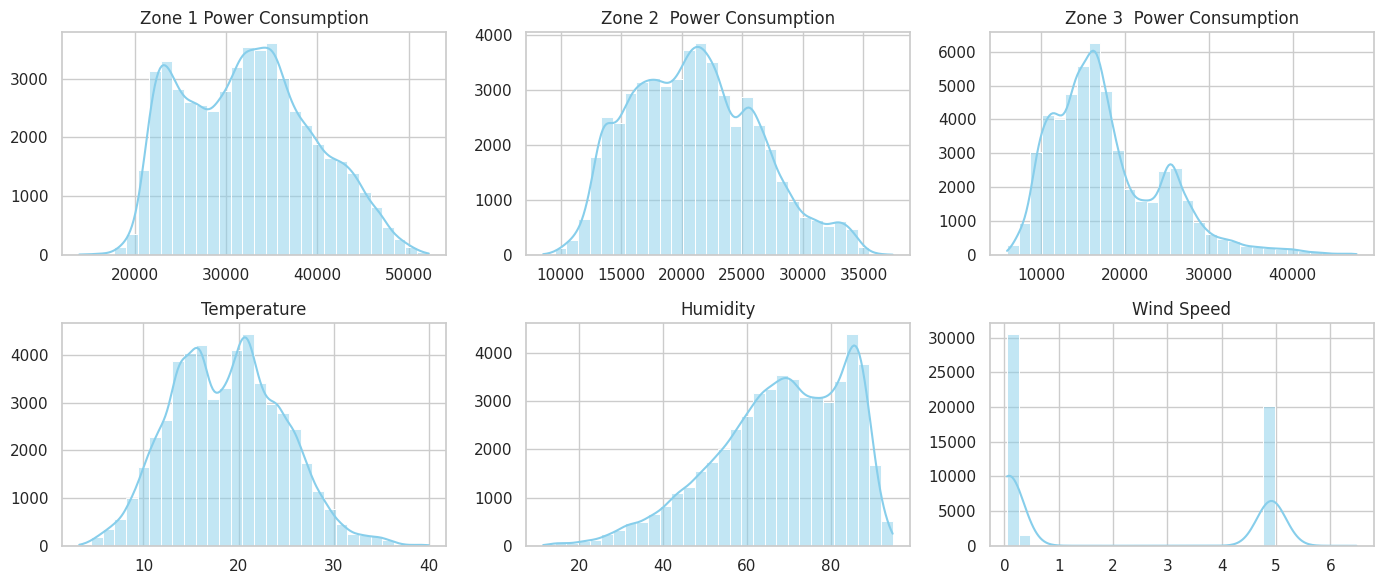

In [88]:
continuas = [
    'Zone 1 Power Consumption',
    'Zone 2  Power Consumption',
    'Zone 3  Power Consumption',
    'Temperature',
    'Humidity',
    'Wind Speed'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))  # 2 filas, 3 columnas
axes = axes.flatten()

for i, var in enumerate(continuas):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


1. **Zone 1:** Presenta los valores de consumo más altos y una distribución amplia con dos picos, lo que sugiere variaciones notables según las horas o días. Es la zona con mayor demanda energética.

2. **Zone 2:** Muestra una distribución más concentrada alrededor del promedio (~21,000). Su consumo es más estable, lo que podría corresponder a un uso residencial o comercial moderado.

3. **Zone 3:** Aunque tiene consumos más bajos, su distribución es más dispersa y asimétrica a la derecha, indicando que hay momentos puntuales de alto consumo.

4. **Temperature:** Presenta una distribución con dos picos, lo que podría reflejar variaciones entre estaciones cálidas y frías a lo largo del año.

5. **Humidity:** Se concentra en valores altos (60–90%), lo que sugiere un ambiente predominantemente húmedo, con pocos registros de baja humedad.

6. **Wind Speed:** Muestra valores muy concentrados cerca de 0 y algunos en torno a 5 km/h, lo que indica que la mayoría de los días el viento es débil, pero hay algunos eventos aislados más intensos.

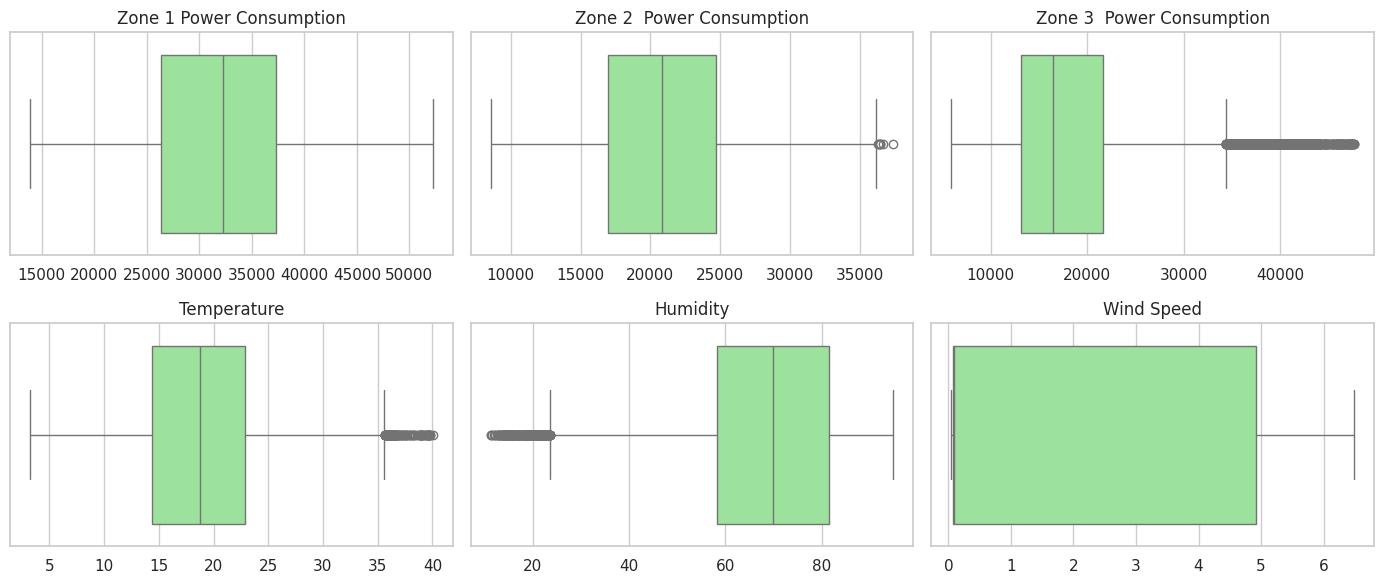

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))  # 2 filas, 3 columnas
axes = axes.flatten()

for i, var in enumerate(continuas):
    sns.boxplot(x=df[var], ax=axes[i], color='lightgreen')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



   - **Zona 1:** Amplio rango intercuartílico y no se observan valores atípicos, reflejando alta variabilidad.  
   - **Zona 2:** Menor rango y pocos outliers, lo que confirma su consumo más estable.  
   - **Zona 3:** Mayor presencia de valores extremos y rango menor, lo que indica comportamientos más irregulares.
   - **Temperatura:** Exhibe varios outliers, reflejando días con temperaturas muy altas.  
   - **Humedad:** También presenta múltiples *outliers*, lo que sugiere una mayor variabilidad en los niveles de humedad baja.  
   - **Velocidad del viento:** No muestra *outliers* visibles; los valores permanecen dentro de un rango acotado, lo que coincide con la predominancia de vientos débiles.


###**Visualizaciones bivariadas**

Se observa un patrón horario claro: el consumo crece durante el día y disminuye en la noche.
Zone 1 mantiene los valores más altos a lo largo del día, mientras que las otras zonas casi no varían.

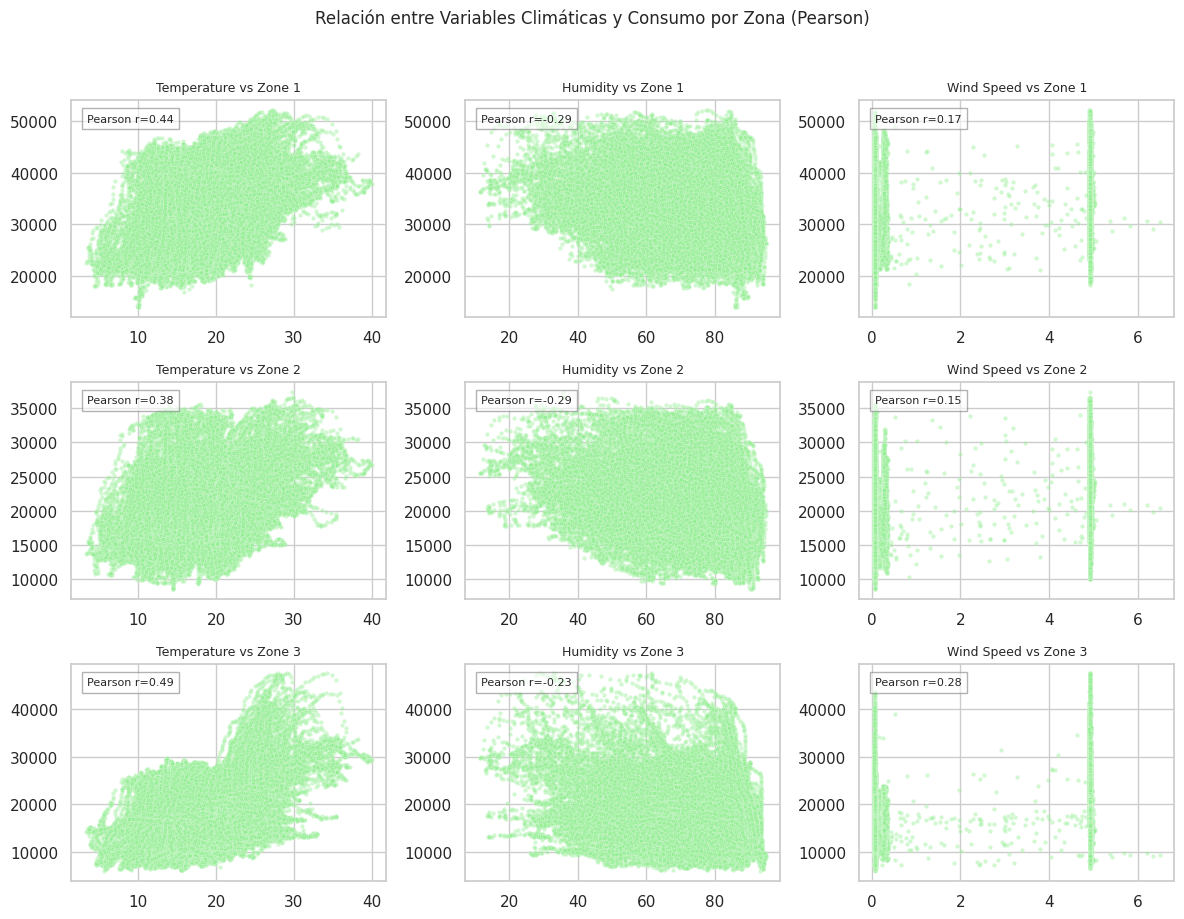

In [90]:

from scipy.stats import pearsonr, spearmanr

sns.set(style="whitegrid")

# Variables
zones = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
climate_vars = ['Temperature', 'Humidity', 'Wind Speed']

# Elegir método
method = 'pearson'

# Crear figura
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for i, zone in enumerate(zones):
    for j, climate_var in enumerate(climate_vars):
        ax = axes[i, j]
        sns.scatterplot(data=df, x=climate_var, y=zone, alpha=0.4, s=10, color='lightgreen', ax=ax)

        # Calcular correlación
        if method == 'pearson':
            r, p = pearsonr(df[climate_var], df[zone])
        else:
            r, p = spearmanr(df[climate_var], df[zone])

        # Mostrar valor
        ax.text(
            0.05, 0.9,
            f"{method.capitalize()} r={r:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
        )

        # Títulos compactos
        ax.set_title(f"{climate_var} vs Zone {zone.split()[1]}", fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')

plt.suptitle(f"Relación entre Variables Climáticas y Consumo por Zona ({method.capitalize()})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**1. Temperatura vs Consumo energético**

En las tres zonas se observa una correlación positiva moderada (r entre 0.38–0.49), lo que significa que a medida que la temperatura aumenta, también lo hace el consumo de energía.

Este patrón podría deberse al uso de sistemas de refrigeración o ventilación en épocas más cálidas.

La Zona 3 muestra la relación más fuerte (r = 0.49), lo que sugiere que es la más sensible a las variaciones de temperatura.

**2. Humedad vs Consumo energético**

La correlación es negativa débil a moderada (r entre -0.23 a -0.29) en todas las zonas.

Esto indica que cuando la humedad aumenta, el consumo tiende a disminuir ligeramente, posiblemente porque el clima húmedo se asocia con temperaturas más templadas o menor uso de equipos de refrigeración.

**3. Velocidad del viento vs Consumo energético**

La relación es muy débil (r entre 0.15 y 0.28), lo que sugiere que el viento tiene poca influencia directa sobre el consumo energético.

Sin embargo, la ligera correlación positiva podría relacionarse con momentos del día o condiciones meteorológicas específicas donde ambos valores coinciden.

**4. Comparación general entre zonas**

La Zona 1 y la Zona 3 presentan los valores más altos de correlación con la temperatura, confirmando que el calor es el principal factor climático asociado al aumento del consumo eléctrico.

Las tres zonas muestran patrones consistentes: la temperatura aumenta el consumo, mientras que la humedad lo reduce.

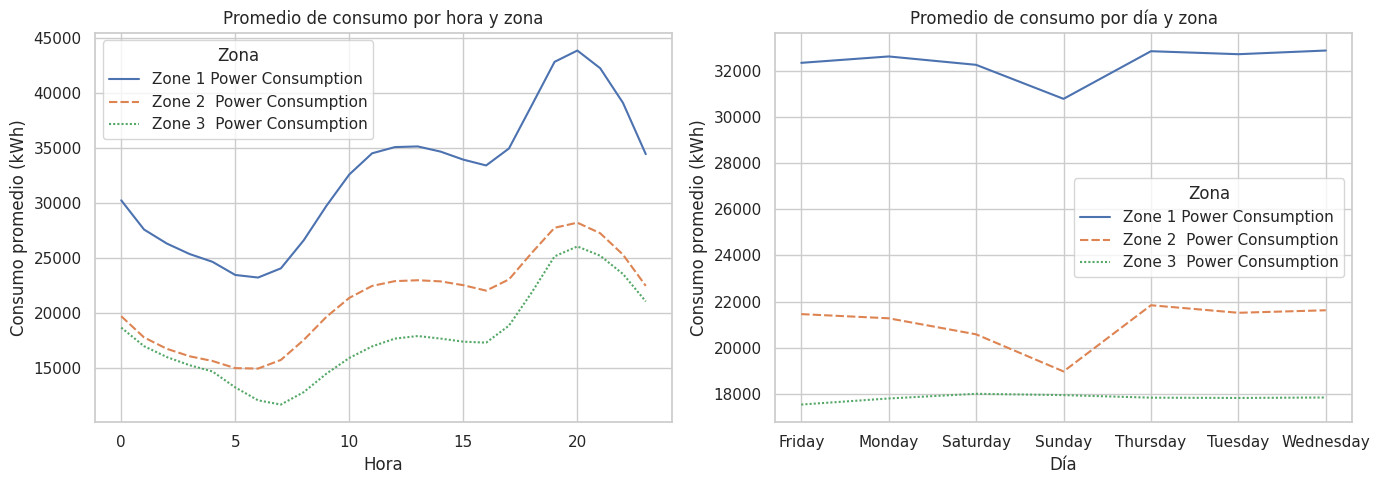

In [92]:



# Crear figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Promedio por hora ---
sns.lineplot(data=df.groupby(['Hour']).mean(numeric_only=True)[['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']],
             ax=axes[0])
axes[0].set_title('Promedio de consumo por hora y zona')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Consumo promedio (kWh)')
axes[0].legend(title='Zona')

# --- Gráfico 2: Promedio por día ---
sns.lineplot(data=df.groupby(['Day']).mean(numeric_only=True)[['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']],
             ax=axes[1])
axes[1].set_title('Promedio de consumo por día y zona')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Consumo promedio (kWh)')
axes[1].legend(title='Zona')

# Ajustar espacio entre gráficos
plt.tight_layout()
plt.show()

**Consumo por hora**

Zona 1 presenta los consumos más altos durante todo el día, con un mínimo entre las 5 y 7 a.m. y un máximo entre las 19 y 21 horas (7–9 p.m.).

Zona 2 muestra una tendencia similar, pero con valores intermedios. El pico nocturno también está entre las 19–21 horas.

Zona 3 es la de menor consumo promedio durante todo el día, con un patrón más estable y un leve aumento al final del día.

**Consumo por dia**

En general, no hay grandes variaciones diarias, lo que sugiere un consumo bastante constante a lo largo de la semana.

Zona 1 mantiene el consumo más alto y estable, con un leve aumento los jueves y martes.

Zona 2 muestra una ligera disminución del consumo el fin de semana (sábado y domingo).

Zona 3 presenta un consumo bajo y muy uniforme, sin variaciones destacables, lo que refuerza su posible carácter de baja demanda energética.

In [93]:

from scipy.stats import chi2_contingency

# Crear tabla de contingencia
contingency_table = pd.crosstab(df['Hour'], df['Day'])

# Prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Estadístico Chi-cuadrado:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)

# Interpretación
if p < 0.05:
    print(" Existe una relación significativa entre la hora y el día.")
else:
    print(" No se observa una relación significativa entre la hora y el día.")


Estadístico Chi-cuadrado: 0.0
Grados de libertad: 138
Valor p: 1.0
 No se observa una relación significativa entre la hora y el día.


###**Visualizaciones multivariadas**





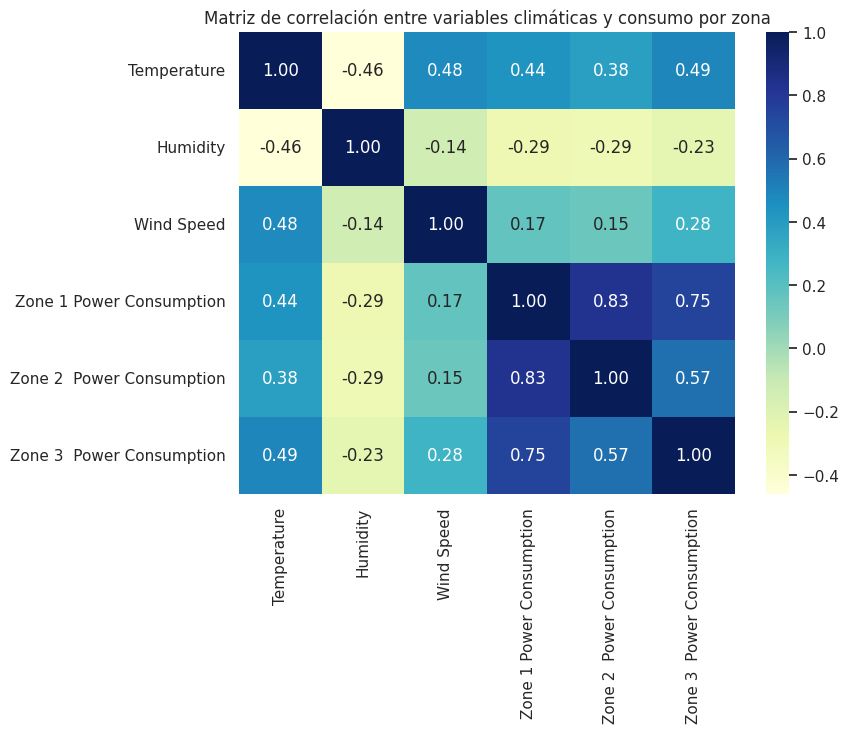

In [94]:


# Seleccionamos solo variables numéricas relevantes
corr_vars = ['Temperature', 'Humidity', 'Wind Speed',
             'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']

# Calculamos correlaciones
corr_matrix = df[corr_vars].corr(method='pearson')

# Graficamos la matriz
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Matriz de correlación entre variables climáticas y consumo por zona')
plt.show()


* El consumo de energía aumenta con la temperatura en las tres zonas; esto puede
estar relacionado con mayor demanda de climatización.

* Las zonas tienen comportamientos energéticos similares (altas correlaciones entre consumos), lo que indica patrones comunes de uso energético urbano.

* La humedad y el viento no parecen tener un impacto fuerte en el consumo, al menos de forma lineal.

* Este patrón respalda que, en el PCA, el primer componente probablemente esté dominado por la temperatura y el consumo energético, mientras que la humedad influya en un componente secundario.

Varianza explicada por componente:
Componente 1: 51.61% (acumulada: 51.61%)
Componente 2: 18.91% (acumulada: 70.52%)
Componente 3: 14.42% (acumulada: 84.93%)
Componente 4: 7.20% (acumulada: 92.14%)
Componente 5: 5.86% (acumulada: 98.00%)
Componente 6: 2.00% (acumulada: 100.00%)


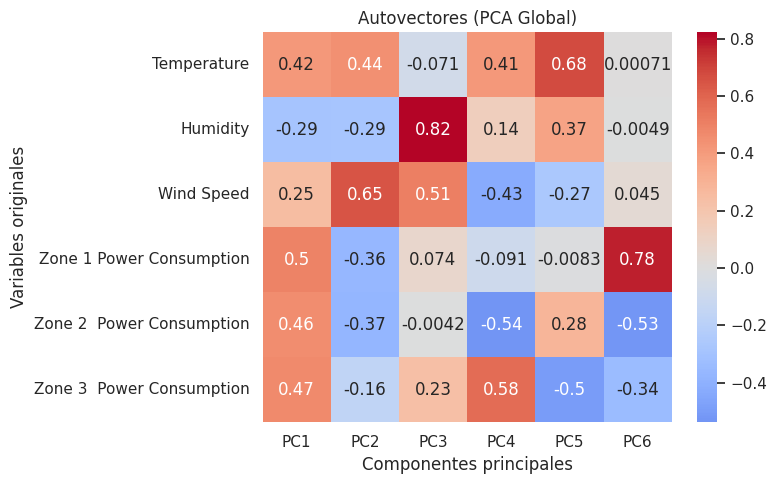

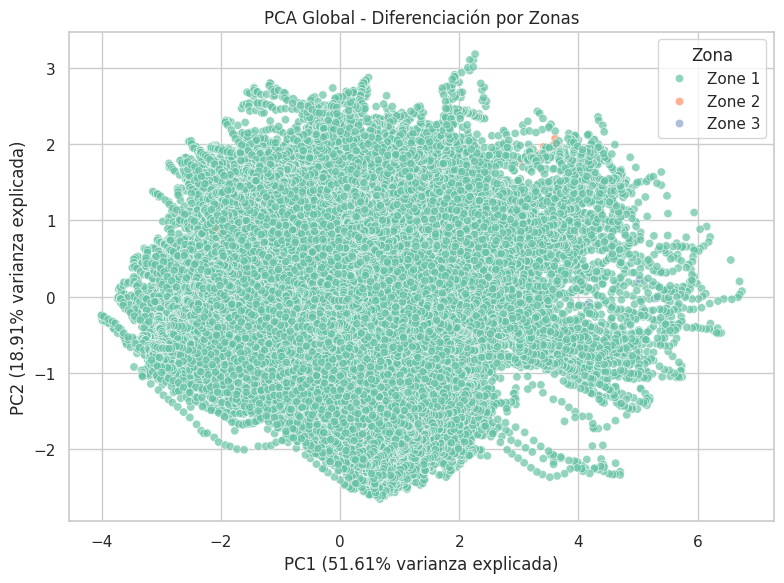

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables climáticas y de consumo (todas las zonas)
variables = ["Temperature", "Humidity", "Wind Speed",
             "Zone 1 Power Consumption", "Zone 2  Power Consumption", "Zone 3  Power Consumption"]

X = df[variables]

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA global
pca_global = PCA()
pca_global.fit(X_scaled)

# Varianza explicada
varianza = pca_global.explained_variance_ratio_ * 100
varianza_acumulada = varianza.cumsum()

print("Varianza explicada por componente:")
for i, v in enumerate(varianza, 1):
    print(f"Componente {i}: {v:.2f}% (acumulada: {varianza_acumulada[i-1]:.2f}%)")

# Matriz de componentes
componentes_global = pd.DataFrame(pca_global.components_.T,
                                  columns=[f'PC{i+1}' for i in range(len(variables))],
                                  index=variables)

# Visualización de autovectores
plt.figure(figsize=(8,5))
sns.heatmap(componentes_global, annot=True, cmap='coolwarm', center=0)
plt.title("Autovectores (PCA Global)")
plt.xlabel("Componentes principales")
plt.ylabel("Variables originales")
plt.tight_layout()
plt.show()

# 🔹 PCA transformado
pca_df_global = pd.DataFrame(pca_global.transform(X_scaled), columns=[f"PC{i+1}" for i in range(X.shape[1])])

# 🔹 Etiquetas por zona (para graficar)
pca_df_global["Zona"] = (
    df[["Zone 1 Power Consumption", "Zone 2  Power Consumption", "Zone 3  Power Consumption"]]
    .idxmax(axis=1)
    .str.extract(r"(Zone \d)")[0]
)

# Gráfico de dispersión (PC1 vs PC2) con color por zona
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df_global, x="PC1", y="PC2", hue="Zona", palette="Set2", alpha=0.7)
plt.title("PCA Global - Diferenciación por Zonas")
plt.xlabel(f"PC1 ({varianza[0]:.2f}% varianza explicada)")
plt.ylabel(f"PC2 ({varianza[1]:.2f}% varianza explicada)")
plt.legend(title="Zona", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


En el PCA global, las variables de consumo de la Zona 1 presentaron mayor varianza y dominancia en los primeros componentes principales, lo que impidió una clara diferenciación de las Zonas 2 y 3. Por esta razón, se realizó un análisis PCA individual por zona, con el fin de evaluar con mayor detalle las relaciones entre las variables climáticas y el consumo energético en cada sector de Tetuán.


🔹 Análisis PCA para Zone 1
Componente 1: 50.44% de varianza explicada (acumulada: 50.44%)
Componente 2: 22.50% de varianza explicada (acumulada: 72.94%)
Componente 3: 17.81% de varianza explicada (acumulada: 90.75%)
Componente 4: 9.25% de varianza explicada (acumulada: 100.00%)

Ecuaciones de los componentes principales:

Componente Principal 1 = 0.615·'Temperature' + -0.468·'Humidity' + 0.428·'Wind Speed' + 0.469·'Zone 1 Power Consumption'
Componente Principal 2 = 0.102·'Temperature' + 0.487·'Humidity' + 0.786·'Wind Speed' + -0.366·'Zone 1 Power Consumption'
Componente Principal 3 = -0.057·'Temperature' + 0.648·'Humidity' + -0.041·'Wind Speed' + 0.759·'Zone 1 Power Consumption'
Componente Principal 4 = 0.78·'Temperature' + 0.353·'Humidity' + -0.444·'Wind Speed' + -0.266·'Zone 1 Power Consumption'


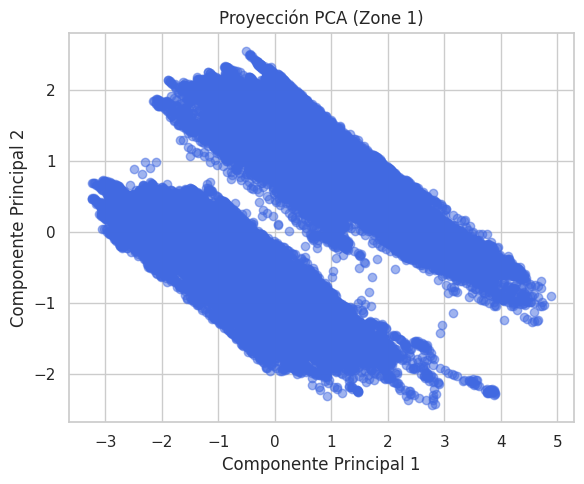


🔹 Análisis PCA para Zone 2
Componente 1: 49.50% de varianza explicada (acumulada: 49.50%)
Componente 2: 23.05% de varianza explicada (acumulada: 72.54%)
Componente 3: 17.78% de varianza explicada (acumulada: 90.32%)
Componente 4: 9.68% de varianza explicada (acumulada: 100.00%)

Ecuaciones de los componentes principales:

Componente Principal 1 = 0.614·'Temperature' + -0.484·'Humidity' + 0.433·'Wind Speed' + 0.45·'Zone 2  Power Consumption'
Componente Principal 2 = 0.139·'Temperature' + 0.439·'Humidity' + 0.764·'Wind Speed' + -0.452·'Zone 2  Power Consumption'
Componente Principal 3 = -0.097·'Temperature' + 0.651·'Humidity' + 0.086·'Wind Speed' + 0.748·'Zone 2  Power Consumption'
Componente Principal 4 = 0.771·'Temperature' + 0.387·'Humidity' + -0.471·'Wind Speed' + -0.183·'Zone 2  Power Consumption'


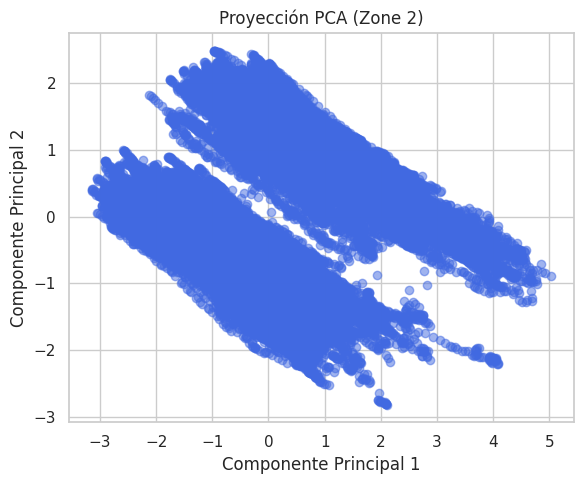


🔹 Análisis PCA para Zone 3
Componente 1: 51.75% de varianza explicada (acumulada: 51.75%)
Componente 2: 21.69% de varianza explicada (acumulada: 73.44%)
Componente 3: 17.48% de varianza explicada (acumulada: 90.93%)
Componente 4: 9.07% de varianza explicada (acumulada: 100.00%)

Ecuaciones de los componentes principales:

Componente Principal 1 = 0.61·'Temperature' + -0.427·'Humidity' + 0.454·'Wind Speed' + 0.49·'Zone 3  Power Consumption'
Componente Principal 2 = -0.023·'Temperature' + 0.769·'Humidity' + 0.629·'Wind Speed' + 0.116·'Zone 3  Power Consumption'
Componente Principal 3 = -0.071·'Temperature' + 0.29·'Humidity' + -0.506·'Wind Speed' + 0.809·'Zone 3  Power Consumption'
Componente Principal 4 = 0.789·'Temperature' + 0.379·'Humidity' + -0.378·'Wind Speed' + -0.302·'Zone 3  Power Consumption'


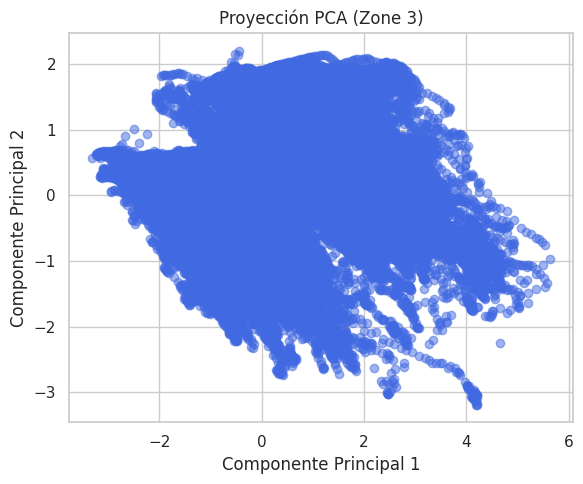

In [96]:


# === 1️⃣ Variables ===
vars_clima = ['Temperature', 'Humidity', 'Wind Speed']
vars_consumo = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
zonas = ['Zone 1', 'Zone 2', 'Zone 3']

# === 2️⃣ PCA por zona ===
for i, zona in enumerate(zonas):
    print(f"\n==============================")
    print(f"🔹 Análisis PCA para {zona}")
    print(f"==============================")

    col_consumo = vars_consumo[i]

    # --- Selección de variables ---
    X = df[vars_clima + [col_consumo]].dropna()

    # --- Escalamiento ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- PCA ---
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # --- Varianza explicada ---
    var_exp = pca.explained_variance_ratio_ * 100
    var_exp_acum = var_exp.cumsum()
    for j, (v, va) in enumerate(zip(var_exp, var_exp_acum)):
        print(f"Componente {j+1}: {v:.2f}% de varianza explicada (acumulada: {va:.2f}%)")


    # --- Ecuaciones de los componentes principales ---
    print("\nEcuaciones de los componentes principales:\n")
    for j in range(pca.components_.shape[0]):
        pesos = pca.components_[j]
        ecuacion = " + ".join(
            [f"{round(pesos[k], 3)}·'{X.columns[k]}'" for k in range(len(pesos))]
        )
        print(f"Componente Principal {j+1} = {ecuacion}")


    # --- Proyección 2D con los dos primeros componentes ---
    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color='royalblue')
    plt.title(f'Proyección PCA ({zona})')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.tight_layout()
    plt.show()

* En la Zona 1, el análisis de componentes principales revela que el consumo energético está principalmente determinado por la temperatura, con una contribución secundaria del viento y una influencia negativa de la humedad. Los dos primeros componentes explican cerca del 73 % de la variabilidad total, evidenciando que los patrones de consumo se relacionan estrechamente con las condiciones climáticas. Esto sugiere que el aumento de temperatura genera una mayor demanda energética, probablemente por el uso intensivo de sistemas de refrigeración.

* En la Zona 2, el análisis de componentes principales muestra que la temperatura es el factor más influyente sobre el consumo energético, con una relación directa y positiva. La humedad presenta una relación inversa, mientras que el viento tiene un efecto dual: refuerza el consumo bajo altas temperaturas, pero lo atenúa cuando aumenta la humedad. Los dos primeros componentes explican más del 72 % de la variabilidad total, confirmando que el comportamiento energético de esta zona depende principalmente de las condiciones climáticas.

* En la Zona 3, el primer componente principal explica el 51.75 % de la variabilidad total, reflejando una relación directa entre la temperatura, el consumo energético y la velocidad del viento, y una relación inversa con la humedad. El segundo componente (21.69 %) captura principalmente la variabilidad atmosférica independiente del consumo. En conjunto, los dos primeros componentes explican el 73.44 % de la varianza total, mostrando que el consumo energético en la Zona 3 depende fuertemente de las condiciones térmicas, aunque con una sensibilidad algo menor frente a cambios de humedad y viento en comparación con las otras zonas.

* En las gráficas de proyección PCA, la Zona 1 muestra una nube de puntos más concentrada, indicando condiciones climáticas más estables. La Zona 2 presenta una dispersión moderada, reflejando una variabilidad intermedia entre temperatura, humedad y consumo energético. En cambio, la Zona 3 exhibe una mayor dispersión, lo que sugiere más fluctuaciones y complejidad climática, coherente con su menor proporción de varianza explicada y un comportamiento energético menos predecible.

## 3. Detección y análisis de atípicos

In [97]:

variables_numericas = ["Temperature", "Humidity", "Wind Speed",
                       "Zone 1 Power Consumption", "Zone 2  Power Consumption", "Zone 3  Power Consumption"]
data = df[variables_numericas]

# ==========================================================
#  MÉTODO 1: IQR (Rango Intercuartílico)
# ==========================================================
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Umbrales
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Detectar atípicos
outliers_iqr = ((data < limite_inferior) | (data > limite_superior)).sum()

print("🔹 Detección de atípicos (IQR):")
print(outliers_iqr)
print("\nPorcentaje de valores atípicos por variable (IQR):")
print((outliers_iqr / len(data) * 100).round(2))




🔹 Detección de atípicos (IQR):
Temperature                   142
Humidity                      291
Wind Speed                      0
Zone 1 Power Consumption        0
Zone 2  Power Consumption       7
Zone 3  Power Consumption    1191
dtype: int64

Porcentaje de valores atípicos por variable (IQR):
Temperature                  0.27
Humidity                     0.56
Wind Speed                   0.00
Zone 1 Power Consumption     0.00
Zone 2  Power Consumption    0.01
Zone 3  Power Consumption    2.27
dtype: float64


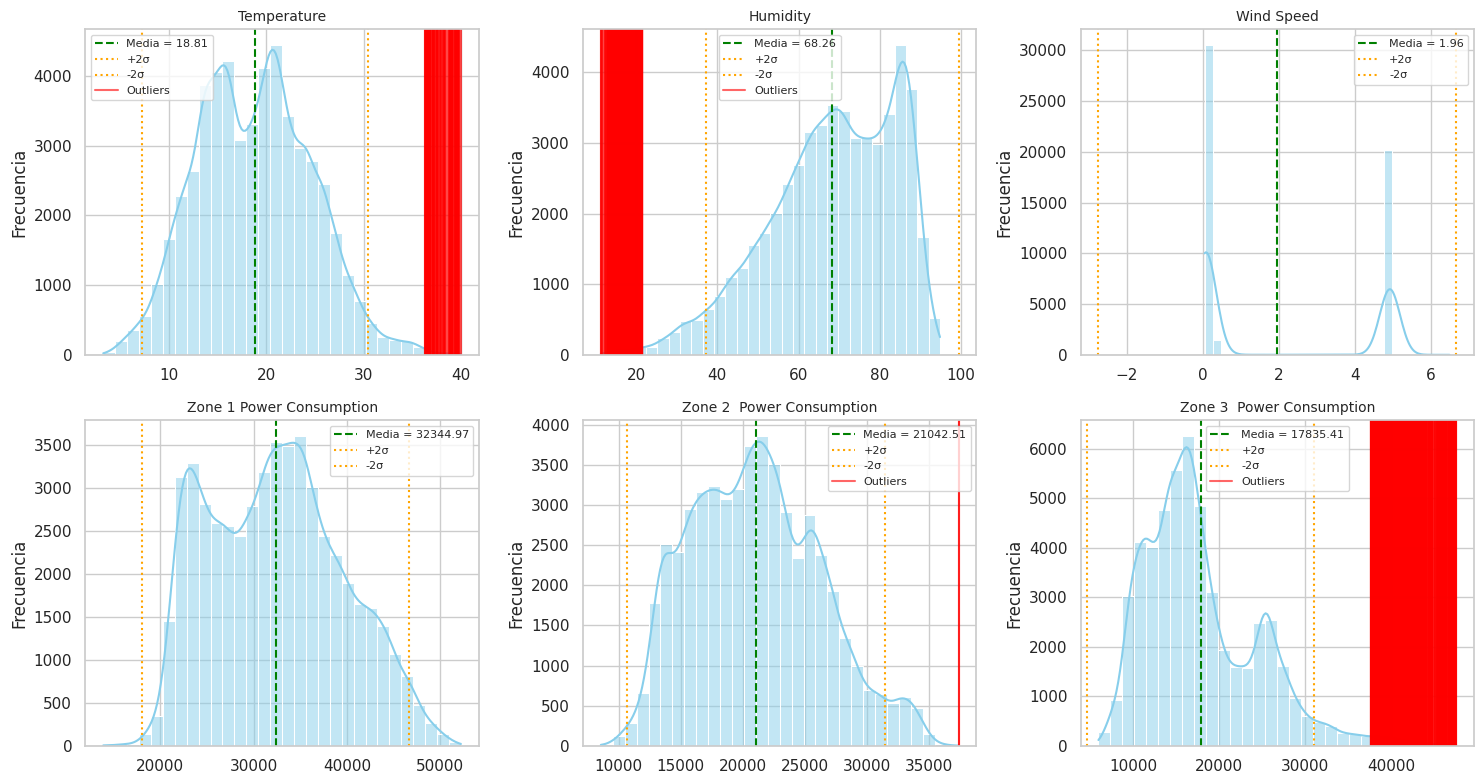

In [98]:

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()  # Para indexar fácilmente

for i, var in enumerate(variables_numericas):
    ax = axes[i]
    data_var = df[var]
    mean = data_var.mean()
    std = data_var.std()
    z_scores = (data_var - mean) / std
    outliers = data_var[np.abs(z_scores) > 3]

    # Histograma con KDE
    sns.histplot(data_var, bins=30, kde=True, color='skyblue', alpha=0.5, ax=ax)

    # Líneas de media y desviaciones
    ax.axvline(mean, color='green', linestyle='--', label=f'Media = {mean:.2f}')
    ax.axvline(mean + 2*std, color='orange', linestyle=':', label='+2σ')
    ax.axvline(mean - 2*std, color='orange', linestyle=':', label='-2σ')

    # Marcar outliers
    for val in outliers:
        ax.axvline(val, color='red', linestyle='-', alpha=0.7)
    if len(outliers) > 0:
        ax.axvline(outliers.iloc[0], color='red', linestyle='-', alpha=0.6, label='Outliers')

    ax.set_title(f"{var}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)


plt.tight_layout()
plt.show()


In [99]:
#  MÉTODO 2: Z-SCORE
# ==========================================================

z_scores = np.abs(stats.zscore(data))
outliers_zscore = (z_scores > 3).sum()

print("\n🔹 Detección de atípicos (Z-Score > 3):")
print(outliers_zscore)
print("\nPorcentaje de valores atípicos por variable (Z-Score):")
print((outliers_zscore / len(data) * 100).round(2))




🔹 Detección de atípicos (Z-Score > 3):
955

Porcentaje de valores atípicos por variable (Z-Score):
1.82


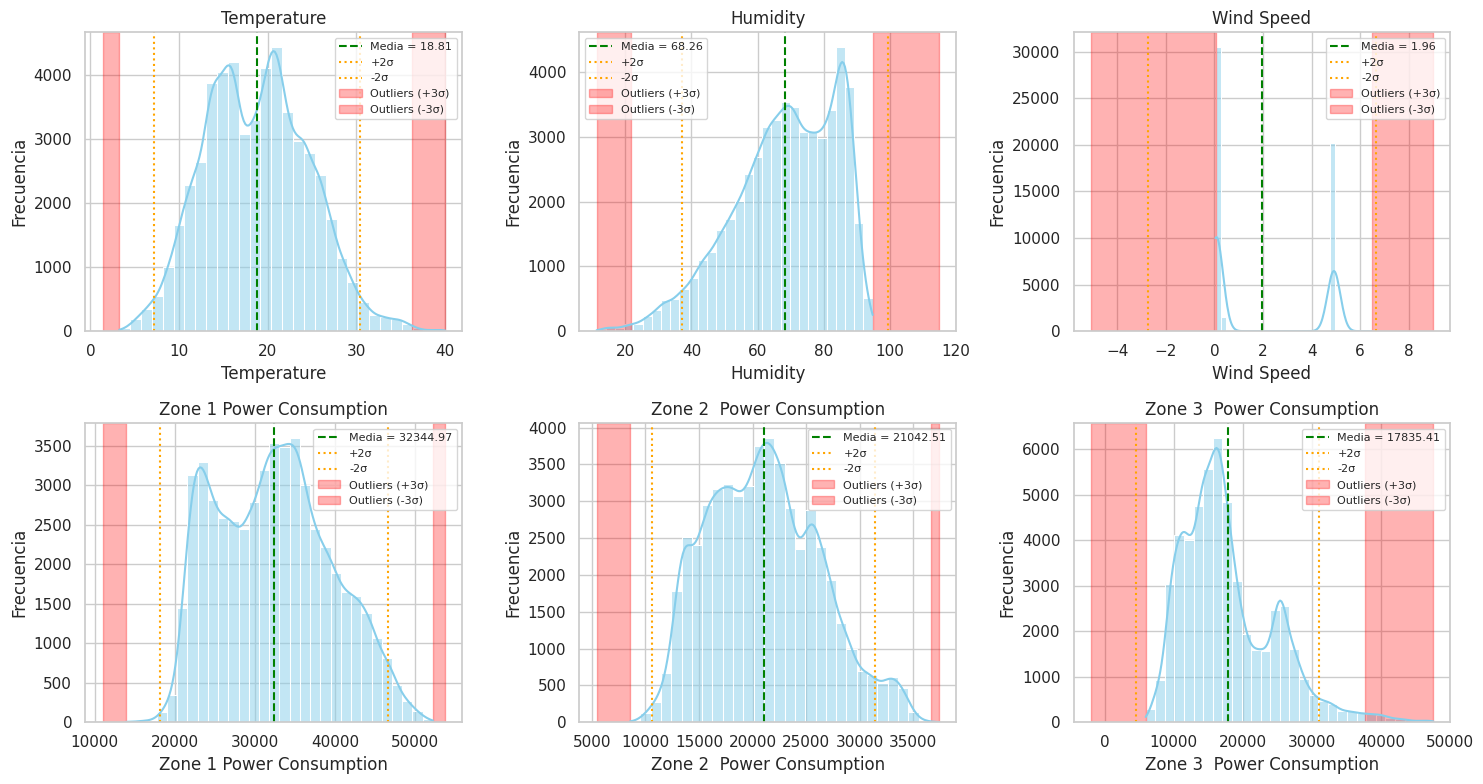

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    data_var = df[var].dropna()

    # Calcular Z-score
    z_scores = np.abs(stats.zscore(data_var))

    # Calcular media y desviación estándar
    mean = data_var.mean()
    std = data_var.std()

    # Determinar outliers con Z > 3
    outliers = data_var[z_scores > 3]

    # Graficar histograma con KDE
    sns.histplot(data_var, bins=30, kde=True, color='skyblue', alpha=0.5, ax=axes[i])

    # Líneas de referencia
    axes[i].axvline(mean, color='green', linestyle='--', label=f'Media = {mean:.2f}')
    axes[i].axvline(mean + 2*std, color='orange', linestyle=':', label='+2σ')
    axes[i].axvline(mean - 2*std, color='orange', linestyle=':', label='-2σ')

    # Sombrear zona de outliers
    axes[i].axvspan(mean + 3*std, data_var.max(), color='red', alpha=0.3, label='Outliers (+3σ)')
    axes[i].axvspan(data_var.min(), mean - 3*std, color='red', alpha=0.3, label='Outliers (-3σ)')

    # Etiquetas y título
    axes[i].set_title(f"{var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

El análisis de valores atípicos mediante los métodos IQR y Z-Score permitió identificar que un pequeño porcentaje de los registros (alrededor del 2 % del total) presenta comportamientos fuera del rango esperado. Los principales valores detectados se concentran en las variables Temperature, Humidity y especialmente Zone 3 Power Consumption, mientras que variables como Wind Speed y Zone 1 Power Consumption mostraron una distribución más estable sin presencia significativa de outliers.

Estas observaciones extremas corresponden en la mayoría de los casos a valores muy altos o muy bajos respecto a la media, lo que sugiere que pueden deberse a condiciones climáticas o de consumo inusuales, como picos de temperatura o humedad atípicos o incrementos de demanda eléctrica en momentos específicos. Sin embargo, también es posible que algunos registros provengan de errores de medición o fallos en la adquisición de datos.

Dado que la proporción de datos atípicos es reducida y que varios de ellos pueden reflejar comportamientos reales del sistema más que errores, no se recomienda eliminarlos de forma inmediata. En su lugar, es conveniente mantenerlos en el conjunto de datos y considerar su transformación o escalado en etapas posteriores del análisis o modelado, especialmente si influyen en la normalidad de las distribuciones o en el desempeño de algoritmos sensibles a valores extremos.



##Conclusión general

El análisis exploratorio permitió comprender el comportamiento general de las variables, revelando distribuciones heterogéneas entre los factores climáticos y el consumo energético por zona. En términos generales, las variables presentan tendencias consistentes, sin sesgos excesivos, aunque algunas muestran asimetrías leves que indican la existencia de periodos o condiciones particulares en los datos. Este análisis inicial permitió identificar la presencia de valores extremos y preparar el terreno para una detección más precisa mediante métodos estadísticos.

A partir de la aplicación de los métodos IQR y Z-Score, se evidenció que el conjunto de datos contiene un bajo porcentaje de valores atípicos (alrededor del 2%), concentrados principalmente en Temperature, Humidity y Zone 3 Power Consumption. Estos casos reflejan situaciones con valores significativamente altos o bajos en comparación con la tendencia general. Las causas probables de estas observaciones incluyen variaciones reales del entorno, como picos de temperatura o humedad inusuales, y posibles errores de medición o registro.
Dado que la magnitud de los atípicos es limitada y varios podrían representar comportamientos genuinos del sistema, se concluye que no deben eliminarse de manera directa.